In [9]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EDA") \
    .master("local[*]") \
    .getOrCreate()

In [46]:
df = spark.read.csv(
    "hdfs://localhost:9000/DACK/weatherAUS.csv",
    header=True,
    inferSchema=True,
    nullValue="NA"
)

Structure Analysis

In [47]:
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- MinTemp: double (nullable = true)
 |-- MaxTemp: double (nullable = true)
 |-- Rainfall: double (nullable = true)
 |-- Evaporation: double (nullable = true)
 |-- Sunshine: double (nullable = true)
 |-- WindGustDir: string (nullable = true)
 |-- WindGustSpeed: integer (nullable = true)
 |-- WindDir9am: string (nullable = true)
 |-- WindDir3pm: string (nullable = true)
 |-- WindSpeed9am: integer (nullable = true)
 |-- WindSpeed3pm: integer (nullable = true)
 |-- Humidity9am: integer (nullable = true)
 |-- Humidity3pm: integer (nullable = true)
 |-- Pressure9am: double (nullable = true)
 |-- Pressure3pm: double (nullable = true)
 |-- Cloud9am: integer (nullable = true)
 |-- Cloud3pm: integer (nullable = true)
 |-- Temp9am: double (nullable = true)
 |-- Temp3pm: double (nullable = true)
 |-- RainToday: string (nullable = true)
 |-- RainTomorrow: string (nullable = true)



In [12]:
print("Số dòng:", df.count())
print("Số cột:", len(df.columns))

Số dòng: 145460
Số cột: 23


In [13]:
total_rows = df.count()
distinct_rows = df.distinct().count()

print("Duplicate rows:", total_rows - distinct_rows)

Duplicate rows: 0


In [14]:
df.show(10)

+----------+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|      Date|Location|MinTemp|MaxTemp|Rainfall|Evaporation|Sunshine|WindGustDir|WindGustSpeed|WindDir9am|WindDir3pm|WindSpeed9am|WindSpeed3pm|Humidity9am|Humidity3pm|Pressure9am|Pressure3pm|Cloud9am|Cloud3pm|Temp9am|Temp3pm|RainToday|RainTomorrow|
+----------+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
| 12/1/2008|  Albury|   13.4|   22.9|     0.6|       NULL|    NULL|          W|           44|         W|       WNW|          20|          24|         71|         22|     1007.7|     1007.1|       8|    NULL|   16.9|   21.8|       No|          No|
| 12/2/2008|

Missing Value Analysis

In [15]:
from pyspark.sql.functions import col, when, count

missing_df = df.select([
    count(
        when(
            col(c).isNull(),
            c
        )
    ).alias(c)
    for c in df.columns
])

missing_df.show()

+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|Date|Location|MinTemp|MaxTemp|Rainfall|Evaporation|Sunshine|WindGustDir|WindGustSpeed|WindDir9am|WindDir3pm|WindSpeed9am|WindSpeed3pm|Humidity9am|Humidity3pm|Pressure9am|Pressure3pm|Cloud9am|Cloud3pm|Temp9am|Temp3pm|RainToday|RainTomorrow|
+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|   0|       0|   1485|   1261|    3261|      62790|   69835|      10326|        10263|     10566|      4228|        1767|        3062|       2654|       4507|      15065|      15028|   55888|   59358|   1767|   3609|     3261|        3267|
+----+--------+-------+-------+-----

In [16]:
from pyspark.sql.functions import *

missing_pct_df = df.select([
    round(
        count(
            when(col(c).isNull(), c)
        ) / count("*") * 100,
        2
    ).alias(c)
    for c in df.columns
])

missing_pct_df.show()

+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
|Date|Location|MinTemp|MaxTemp|Rainfall|Evaporation|Sunshine|WindGustDir|WindGustSpeed|WindDir9am|WindDir3pm|WindSpeed9am|WindSpeed3pm|Humidity9am|Humidity3pm|Pressure9am|Pressure3pm|Cloud9am|Cloud3pm|Temp9am|Temp3pm|RainToday|RainTomorrow|
+----+--------+-------+-------+--------+-----------+--------+-----------+-------------+----------+----------+------------+------------+-----------+-----------+-----------+-----------+--------+--------+-------+-------+---------+------------+
| 0.0|     0.0|   1.02|   0.87|    2.24|      43.17|   48.01|        7.1|         7.06|      7.26|      2.91|        1.21|        2.11|       1.82|        3.1|      10.36|      10.33|   38.42|   40.81|   1.21|   2.48|     2.24|        2.25|
+----+--------+-------+-------+-----

In [17]:
from pyspark.sql.functions import *
import pandas as pd

missing_pct = df.select([
    round(
        count(when(col(c).isNull(), c)) / count("*") * 100,
        2
    ).alias(c)
    for c in df.columns
]).first().asDict()

missing_vl_df = pd.DataFrame([
    [
        c,
        p,
        (
            "No Missing" if p == 0 else
            "Low Missing" if p < 5 else
            "Moderate Missing" if p < 30 else
            "High Missing" if p < 50 else
            "Critical Missing"
        )
    ]
    for c, p in sorted(
        missing_pct.items(),
        key=lambda x: x[1],
        reverse=True
    )
],
columns=[
    "Column",
    "MissingPercent",
    "Severity"
])

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

missing_vl_df

,Column,MissingPercent,Severity
0,Sunshine,48.01,High Missing
1,Evaporation,43.17,High Missing
2,Cloud3pm,40.81,High Missing
3,Cloud9am,38.42,High Missing
4,Pressure9am,10.36,Moderate Missing
5,Pressure3pm,10.33,Moderate Missing
6,WindDir9am,7.26,Moderate Missing
7,WindGustDir,7.10,Moderate Missing
8,WindGustSpeed,7.06,Moderate Missing
9,Humidity3pm,3.10,Low Missing


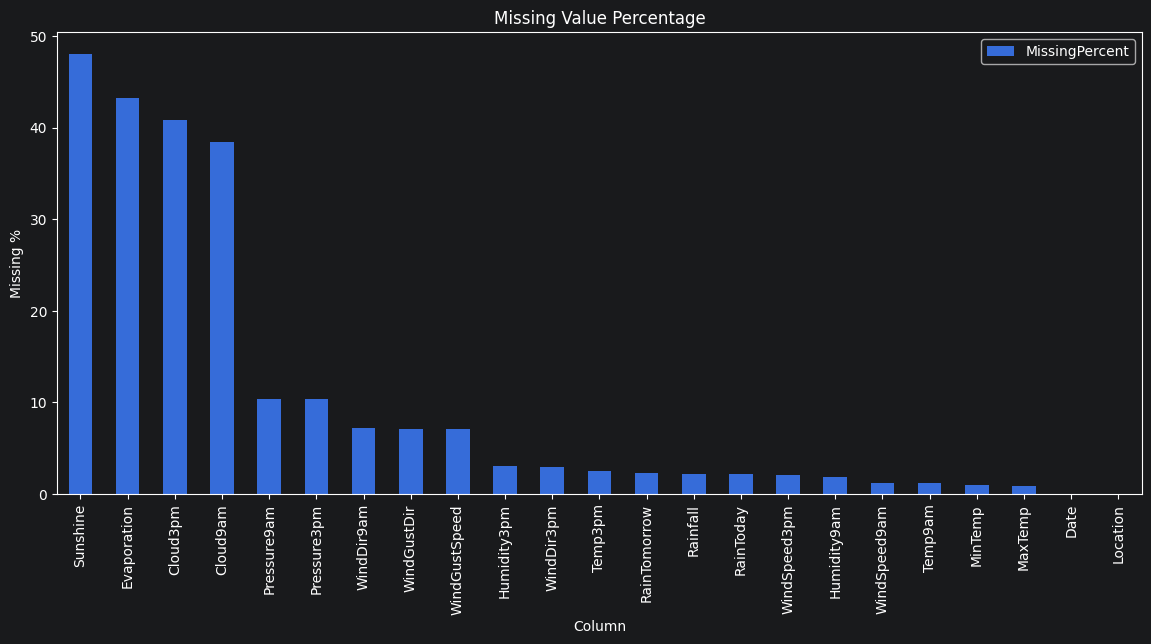

In [18]:
import matplotlib.pyplot as plt

missing_vl_df = missing_vl_df.sort_values(
    by="MissingPercent",
    ascending=False
)

missing_vl_df.plot.bar(
    x="Column",
    y="MissingPercent",
    figsize=(14,6)
)

plt.title("Missing Value Percentage")
plt.ylabel("Missing %")
plt.xticks(rotation=90)

plt.show()

Descriptive Statistics

In [19]:
df.describe().show()

+-------+--------+--------+------------------+------------------+------------------+-----------------+-----------------+-----------+------------------+----------+----------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+---------+------------+
|summary|    Date|Location|           MinTemp|           MaxTemp|          Rainfall|      Evaporation|         Sunshine|WindGustDir|     WindGustSpeed|WindDir9am|WindDir3pm|      WindSpeed9am|      WindSpeed3pm|       Humidity9am|       Humidity3pm|       Pressure9am|       Pressure3pm|          Cloud9am|          Cloud3pm|          Temp9am|          Temp3pm|RainToday|RainTomorrow|
+-------+--------+--------+------------------+------------------+------------------+-----------------+-----------------+-----------+------------------+----------+----------+------------------+------------------+------------------+

In [48]:
from pyspark.sql.types import *

numeric_cols = [

    field.name

    for field in df.schema.fields

    if isinstance(
        field.dataType,
        (
            IntegerType,
            DoubleType
        )
    )
]

print(numeric_cols)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [21]:
for c in numeric_cols:

    median = df.approxQuantile(
        c,
        [0.5],
        0
    )[0]

    print(f"{c} median:", median)

MinTemp median: 12.0
MaxTemp median: 22.6
Rainfall median: 0.0
Evaporation median: 4.8
Sunshine median: 8.4
WindGustSpeed median: 39.0
WindSpeed9am median: 13.0
WindSpeed3pm median: 19.0
Humidity9am median: 70.0
Humidity3pm median: 52.0
Pressure9am median: 1017.6
Pressure3pm median: 1015.2
Cloud9am median: 5.0
Cloud3pm median: 5.0
Temp9am median: 16.7
Temp3pm median: 21.1


In [22]:

from pyspark.sql import functions as F

for c in ["Rainfall", "Humidity3pm", "MaxTemp"]:

    skew_val = df.select(
        F.skewness(c)
    ).collect()[0][0]

    kurt_val = df.select(
        F.kurtosis(c)
    ).collect()[0][0]

    print(f"{c}:")
    print(f"  Skewness : {skew_val:.2f}")
    print(f"  Kurtosis : {kurt_val:.2f}")

Rainfall:
  Skewness : 9.84
  Kurtosis : 178.15
Humidity3pm:
  Skewness : 0.03
  Kurtosis : -0.51
MaxTemp:
  Skewness : 0.22
  Kurtosis : -0.22


Categorical Analysis


In [23]:
df.groupBy("RainTomorrow").count().show()

+------------+------+
|RainTomorrow| count|
+------------+------+
|        NULL|  3267|
|          No|110316|
|         Yes| 31877|
+------------+------+



In [49]:
categorical_cols = [
    "Location",
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday",
    "RainTomorrow"
]

for c in categorical_cols:

    print(f"\n{c}")

    print(
        "Distinct values:",
        df.select(c).distinct().count()
    )

    df.groupBy(c) \
      .count() \
      .orderBy(F.desc("count")) \
      .show(30)


Location
Distinct values: 49
+-------------+-----+
|     Location|count|
+-------------+-----+
|     Canberra| 3436|
|       Sydney| 3344|
|     Brisbane| 3193|
|    Melbourne| 3193|
|     Adelaide| 3193|
|        Perth| 3193|
|       Hobart| 3193|
|       Darwin| 3193|
|   Wollongong| 3040|
|       Albury| 3040|
|      Bendigo| 3040|
|     Ballarat| 3040|
|  MountGinini| 3040|
|       Cairns| 3040|
|       Albany| 3040|
|    GoldCoast| 3040|
| MountGambier| 3040|
|   Townsville| 3040|
| AliceSprings| 3040|
|   Launceston| 3040|
|      Penrith| 3039|
|    Newcastle| 3039|
|  Tuggeranong| 3039|
|NorfolkIsland| 3009|
|        Cobar| 3009|
|SydneyAirport| 3009|
|  Williamtown| 3009|
|        Moree| 3009|
|BadgerysCreek| 3009|
|   WaggaWagga| 3009|
+-------------+-----+
only showing top 30 rows

WindGustDir
Distinct values: 17
+-----------+-----+
|WindGustDir|count|
+-----------+-----+
|       NULL|10326|
|          W| 9915|
|         SE| 9418|
|          N| 9313|
|        SSE| 9216|
|   

Target Analysis

countplot

+------------+------+
|RainTomorrow| count|
+------------+------+
|        NULL|  3267|
|          No|110316|
|         Yes| 31877|
+------------+------+



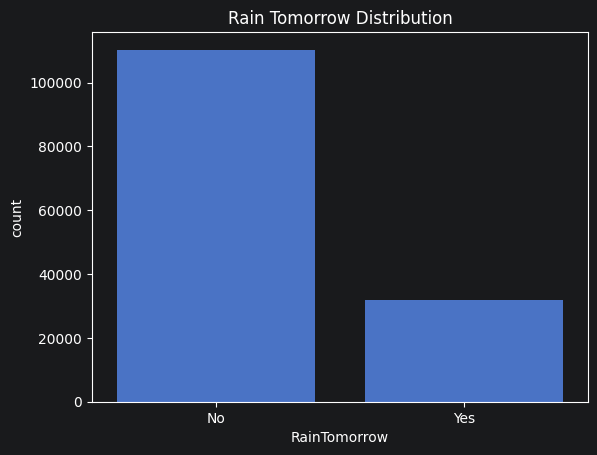

In [25]:
df.groupBy("RainTomorrow") \
  .count() \
  .show()

pdf = df.toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="RainTomorrow",
    data=pdf
)

plt.title("Rain Tomorrow Distribution")
plt.show()

In [26]:
df = spark.read.csv(
    "hdfs://localhost:9000/DACK/weatherAUS.csv",
    header=True,
    inferSchema=True,
    nullValue="NA"
)

In [27]:
#convert datatype
from pyspark.sql.functions import col
numeric_cols = [
    "MinTemp", "MaxTemp", "Rainfall",
    "Evaporation", "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm",
    "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm",
    "Temp9am", "Temp3pm"
]

for c in numeric_cols:
   df = df.withColumn(c, col(c).try_cast("double"))

In [28]:
from pyspark.sql.functions import to_date

df = df.withColumn(
    "Date",
    to_date(col("Date"), "yyyy-MM-dd")
)

Feature Interaction Analysis

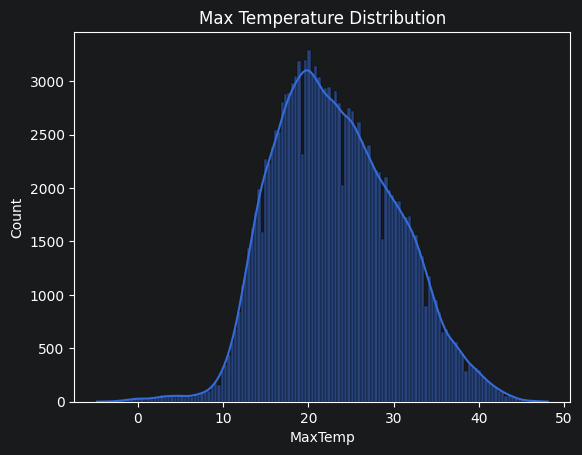

In [29]:
sns.histplot(
    pdf["MaxTemp"],
    kde=True
)

plt.title("Max Temperature Distribution")
plt.show()

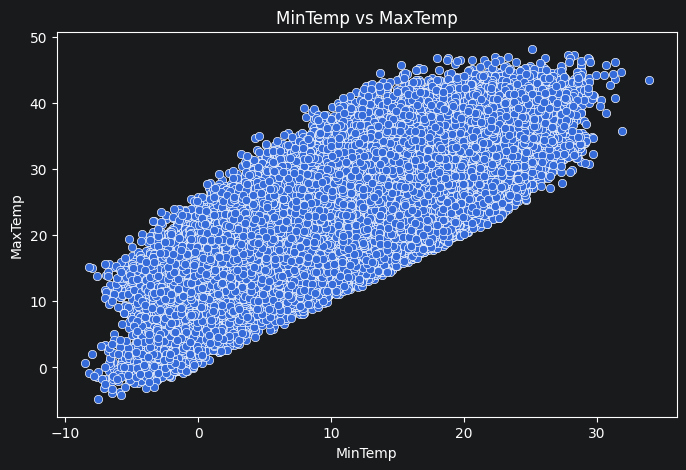

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=pdf["MinTemp"],
    y=pdf["MaxTemp"]
)

plt.title("MinTemp vs MaxTemp")
plt.show()

In [31]:
pdf["Rainfall"].head()

0    0.6
1    0.0
2    0.0
3    0.0
4    1.0
Name: Rainfall, dtype: float64

In [32]:
pdf["Rainfall"].isna().sum()

np.int64(3261)

Text(0, 0.5, 'Frequency')

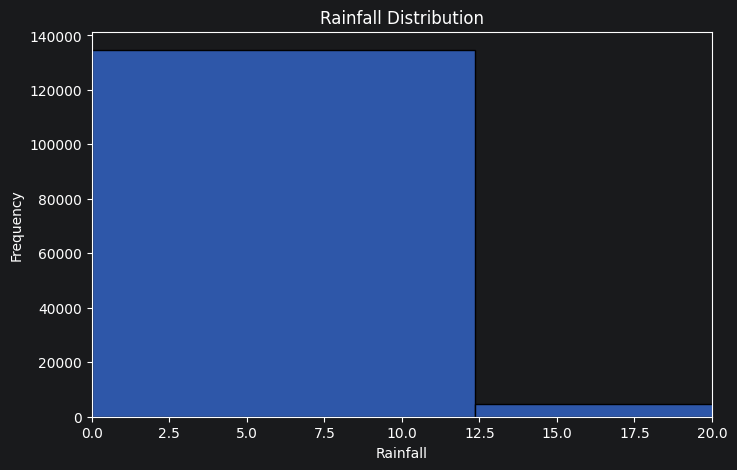

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    pdf["Rainfall"].dropna(),
    bins=30
)

plt.xlim(0, 20)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")


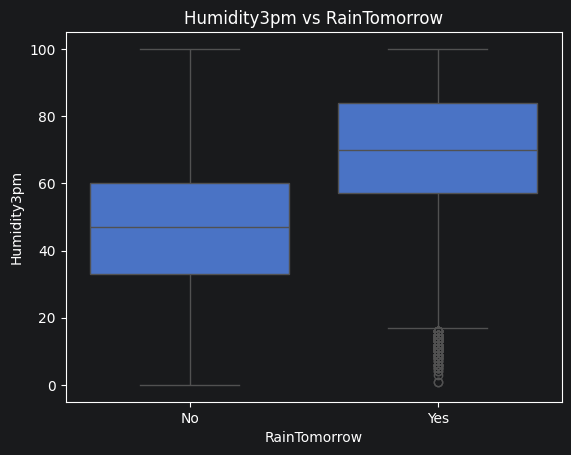

In [34]:
sns.boxplot(
    x="RainTomorrow",
    y="Humidity3pm",
    data=pdf
)

plt.title("Humidity3pm vs RainTomorrow")
plt.show()

Outlier Analysis

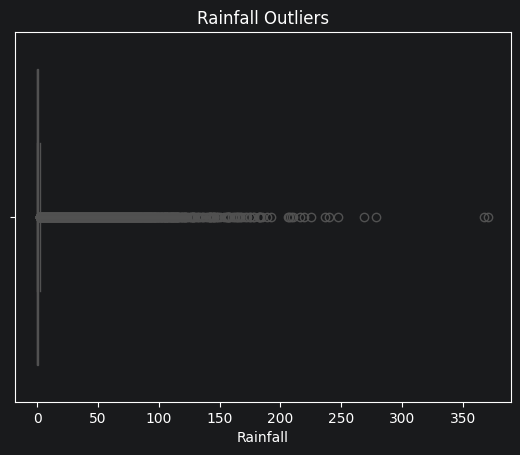

In [35]:
sns.boxplot(
    x=pdf["Rainfall"]
)

plt.title("Rainfall Outliers")
plt.show()

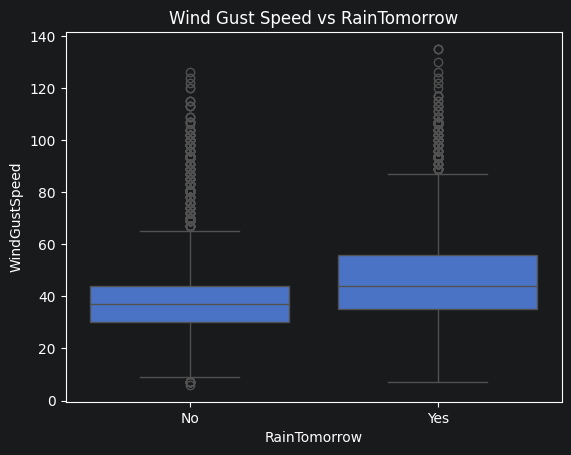

In [36]:
sns.boxplot(
    x="RainTomorrow",
    y="WindGustSpeed",
    data=pdf
)

plt.title("Wind Gust Speed vs RainTomorrow")
plt.show()

In [37]:
Q1 = df.approxQuantile(
    "Rainfall",
    [0.25],
    0
)[0]

Q3 = df.approxQuantile(
    "Rainfall",
    [0.75],
    0
)[0]

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df.filter(
    (F.col("Rainfall") < lower_bound) |
    (F.col("Rainfall") > upper_bound)
)

print("Outlier count:", outliers.count())

Outlier count: 25578


Correlation Analysis

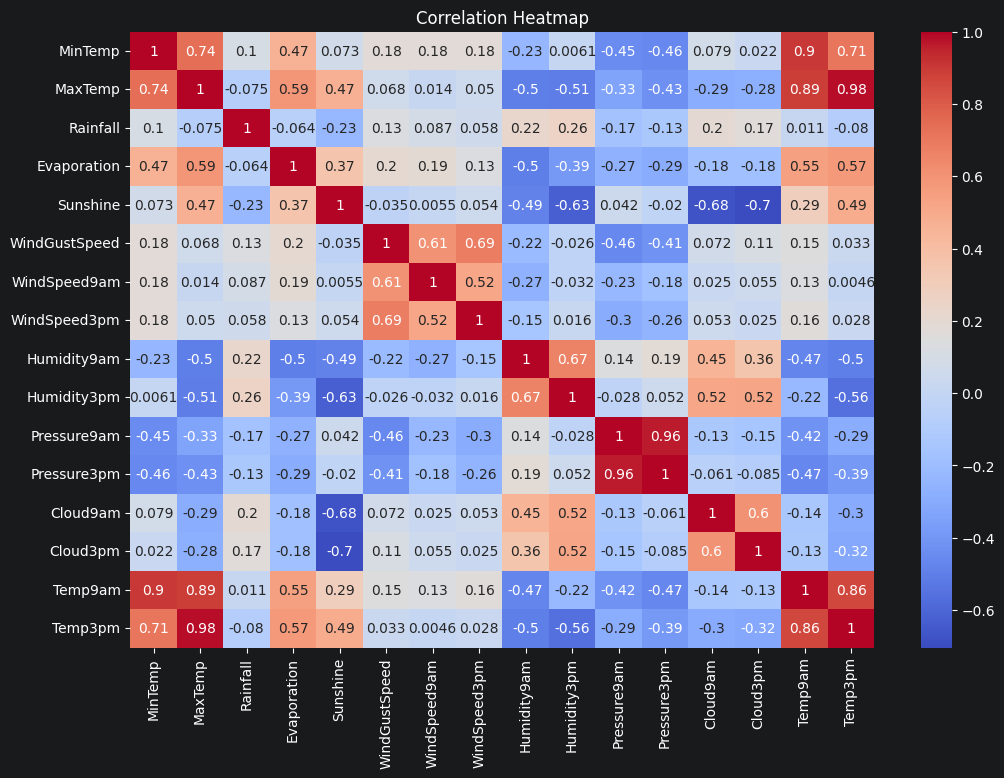

In [38]:
numeric_df = pdf.select_dtypes(
    include=['float64', 'int64']
)
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Time & Geographic Analysis

Tạo derived column (month, date, year)

In [50]:
from pyspark.sql.functions import (
    to_timestamp,
    month,
    year,
    col
)
# parse date đúng format
df = df.withColumn(
    "DateParsed",
    to_timestamp(col("Date"), "M/d/yyyy")
)

# extract month/year
df = df.withColumn(
    "Month",
    month(col("DateParsed"))
)

df = df.withColumn(
    "Year",
    year(col("DateParsed"))
)

df.select(
    "Date",
    "DateParsed",
    "Month",
    "Year"
).show(5, truncate=False)

+---------+-------------------+-----+----+
|Date     |DateParsed         |Month|Year|
+---------+-------------------+-----+----+
|12/1/2008|2008-12-01 00:00:00|12   |2008|
|12/2/2008|2008-12-02 00:00:00|12   |2008|
|12/3/2008|2008-12-03 00:00:00|12   |2008|
|12/4/2008|2008-12-04 00:00:00|12   |2008|
|12/5/2008|2008-12-05 00:00:00|12   |2008|
+---------+-------------------+-----+----+
only showing top 5 rows


In [52]:
monthly_rain = df.groupBy("Month") \
    .agg(
        avg("Rainfall").alias("avg_rainfall")
    ) \
    .orderBy("Month")

monthly_pdf = monthly_rain.toPandas()

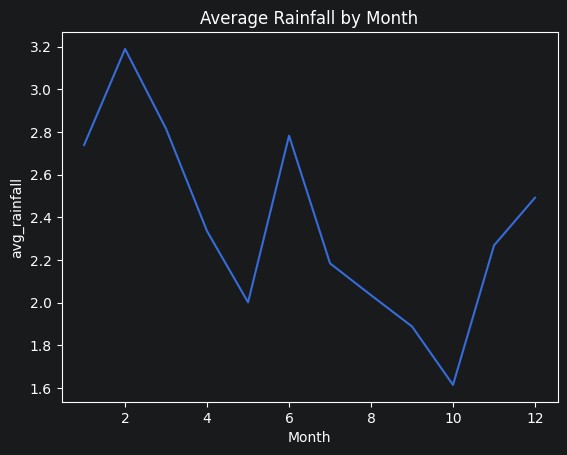

In [53]:
sns.lineplot(
    x="Month",
    y="avg_rainfall",
    data=monthly_pdf
)

plt.title("Average Rainfall by Month")
plt.show()

In [54]:
from pyspark.sql.functions import avg

df.groupBy("Location") \
  .agg(
      avg("Rainfall").alias("avg_rainfall")
  ) \
  .orderBy(
      col("avg_rainfall").desc()
  ) \
  .show(10)

+------------+------------------+
|    Location|      avg_rainfall|
+------------+------------------+
|      Cairns| 5.742034805890243|
|      Darwin| 5.092452239273417|
|CoffsHarbour| 5.061496782932628|
|   GoldCoast|3.7693959731543734|
|  Wollongong|3.5949027498323236|
| Williamtown|3.5911084998041507|
|  Townsville|3.4855918232772836|
|   NorahHead|3.3872994195971353|
|      Sydney| 3.324543002697027|
| MountGinini|3.2922600619195004|
+------------+------------------+
only showing top 10 rows


In [55]:
df.groupBy("Location") \
  .agg(
      avg("MaxTemp").alias("avg_max_temp")
  ) \
  .orderBy(
      col("avg_max_temp").desc()
  ) \
  .show(10)

+------------+------------------+
|    Location|      avg_max_temp|
+------------+------------------+
|   Katherine| 34.93543563068914|
|      Darwin| 32.54097744360893|
|       Uluru|30.383195416931855|
|      Cairns|29.558848684210492|
|  Townsville|29.367160250082158|
|AliceSprings|29.248420013166562|
|       Moree|26.950548354935197|
|     Woomera| 26.59670658682631|
|    Brisbane|26.448379993708762|
|  PearceRAAF|26.051238286479286|
+------------+------------------+
only showing top 10 rows


In [57]:
df_month = df.withColumn(
   "Month",
   F.month("DateParsed")
)

df_month.groupBy("Month") \
       .agg(
           F.avg("Rainfall").alias("AvgRainfall"),
           F.avg("MaxTemp").alias("AvgTemp")
       ) \
       .orderBy("Month") \
       .show()

+-----+------------------+------------------+
|Month|       AvgRainfall|           AvgTemp|
+-----+------------------+------------------+
|    1|2.7384776211863104|29.532383498854056|
|    2|3.1886650831353904|28.873509002250582|
|    3|2.8144500690289935|26.885273428636243|
|    4|2.3348226134654433|  23.6250350262697|
|    5| 2.001654158370343|20.065173453996977|
|    6| 2.782182052937378|17.307647666746153|
|    7|   2.1842091858392|16.744580229346298|
|    8|2.0349825724730035|18.241012552301264|
|    9| 1.888543227284738|20.752011767759804|
|   10|1.6147320294640533|23.537153156174035|
|   11| 2.268177056050282|26.181246766683913|
|   12|2.4918354137771552|27.558321194464686|
+-----+------------------+------------------+

